In [ ]:
# ===============================================
# 🧠 Deep Convolutional GAN (DCGAN)
# 🎯 Goal: Generate Human Faces from Noise
# Dataset: CelebA
# Framework: PyTorch
# ===============================================

# ✅ Install dependencies (uncomment in Colab)
# !pip install torch torchvision tqdm tensorboard



In [1]:
!pip install torch torchvision tqdm tensorboard

In [2]:
# import libraries and setup config
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Configuration
class Config:
    data_root = "./data/celeba"
    image_size = 64
    channels = 3
    nz = 100           # latent vector size
    ngf = 64           # generator feature map size
    ndf = 64           # discriminator feature map size
    batch_size = 128
    epochs = 10        # increase to 50+ for better results
    lr = 0.0002
    beta1 = 0.5
    workers = 2
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"
    out_dir = "./outputs"
    checkpoint_dir = "./checkpoints"

cfg = Config()

# Setup device and seeds
os.makedirs(cfg.out_dir, exist_ok=True)
os.makedirs(cfg.checkpoint_dir, exist_ok=True)
random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
print(f"Device: {cfg.device}")


Device: cuda


In [3]:
# Define weight initials
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [4]:
# Define Generator
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)


In [5]:
# Define Discriminator
class Discriminator(nn.Module):
    def __init__(self, ndf, nc):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)


In [6]:
# Load Celebrities Dataset
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = datasets.CelebA(root=cfg.data_root, split="train", download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.workers)

print(f"Loaded {len(dataset)} images.")


Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=5a2e3c80-c1c1-49cd-9c9d-c746a09ba7cf
To: /content/data/celeba/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:10<00:00, 143MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/data/celeba/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 87.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/data/celeba/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 31.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/data/celeba/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 54.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /con

Loaded 162770 images.


In [7]:
# initialize model
netG = Generator(cfg.nz, cfg.ngf, cfg.channels).to(cfg.device)
netD = Discriminator(cfg.ndf, cfg.channels).to(cfg.device)
netG.apply(weights_init_normal)
netD.apply(weights_init_normal)

print(netG)
print(netD)


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [8]:
# Setup loss and optimizers
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, cfg.nz, 1, 1, device=cfg.device)
real_label = 1.0
fake_label = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=cfg.lr, betas=(cfg.beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=cfg.lr, betas=(cfg.beta1, 0.999))


In [9]:
# Training Loop
img_list = []
G_losses, D_losses = [], []

print("🚀 Starting Training...")

for epoch in range(cfg.epochs):
    for i, data in enumerate(tqdm(dataloader)):
        # Train Discriminator
        netD.zero_grad()
        real = data[0].to(cfg.device)
        b_size = real.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=cfg.device)
        output = netD(real)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, cfg.nz, 1, 1, device=cfg.device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Track losses
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 500 == 0:
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(utils.make_grid(fake, padding=2, normalize=True))

    print(f"Epoch [{epoch+1}/{cfg.epochs}]  D_loss: {errD.item():.4f}, G_loss: {errG.item():.4f}")

print("✅ Training Complete!")


🚀 Starting Training...


100%|██████████| 1272/1272 [03:38<00:00,  5.82it/s]


Epoch [1/10]  D_loss: 0.4307, G_loss: 2.3209


100%|██████████| 1272/1272 [03:36<00:00,  5.89it/s]


Epoch [2/10]  D_loss: 0.6896, G_loss: 2.0746


...

Epoch [8/10]  D_loss: 0.5267, G_loss: 1.9195


100%|██████████| 1272/1272 [03:30<00:00,  6.03it/s]


Epoch [9/10]  D_loss: 1.1080, G_loss: 5.2997


100%|██████████| 1272/1272 [03:30<00:00,  6.04it/s]

Epoch [10/10]  D_loss: 0.7198, G_loss: 4.5205
✅ Training Complete!


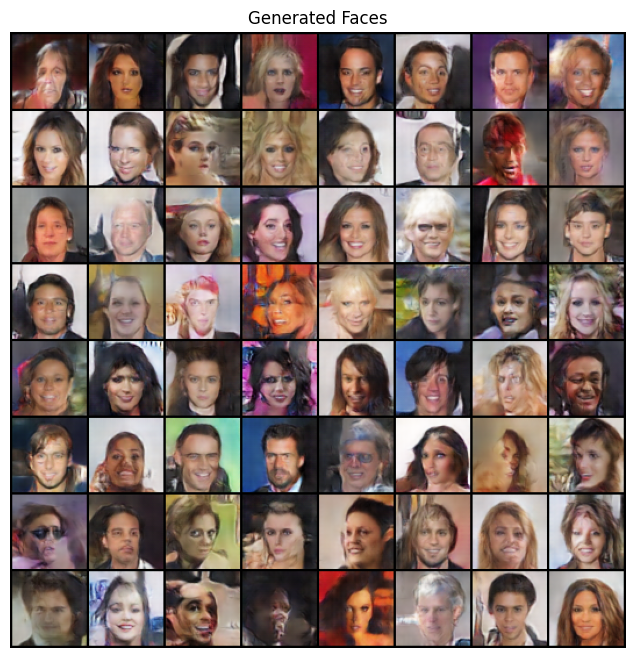

In [13]:
import numpy as np

# Visualize Generated Faces
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Faces")
plt.imshow(
    np.transpose(img_list[-1], (1,2,0))
)
plt.show()


In [12]:
# Save and Reload Generator
torch.save(netG.state_dict(), os.path.join(cfg.checkpoint_dir, "netG_final.pth"))

# Generate new faces
netG.load_state_dict(torch.load(os.path.join(cfg.checkpoint_dir, "netG_final.pth")))
netG.eval()

noise = torch.randn(64, cfg.nz, 1, 1, device=cfg.device)
with torch.no_grad():
    fake_faces = netG(noise).detach().cpu()

utils.save_image((fake_faces + 1) / 2, os.path.join(cfg.out_dir, "generated_faces.png"), nrow=8)
print("🖼️ Saved generated faces to ./outputs/generated_faces.png")


🖼️ Saved generated faces to ./outputs/generated_faces.png


In [ ]:
# Save the Trained Model
torch.save(netG.state_dict(), "generator_dcgan.pth")

In [ ]:
# Create first API
face-gan-api/
├── app.py
├── generator_dcgan.pth
├── models/
│   └── generator.py
├── requirements.txt
└── Dockerfile  (optional)


In [ ]:
# models/generator.py
import torch
import torch.nn as nn

# DCGAN Generator definition (same as training)
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)


In [ ]:
# app.py
from fastapi import FastAPI
from fastapi.responses import FileResponse
import torch
import torchvision.utils as vutils
import uuid
from models.generator import Generator

app = FastAPI(title="FaceGAN API")

# --- Model setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "generator_dcgan.pth"

# Initialize and load weights
netG = Generator(nz=100, ngf=64, nc=3).to(device)
netG.load_state_dict(torch.load(model_path, map_location=device))
netG.eval()

@app.get("/")
def root():
    return {"message": "FaceGAN API is running!"}

@app.get("/generate")
def generate_faces(num_samples: int = 4):
    """
    Generate synthetic human faces.
    num_samples: number of images to generate (1–64)
    Returns: saved image path
    """
    num_samples = min(max(1, num_samples), 64)
    z = torch.randn(num_samples, 100, 1, 1, device=device)
    with torch.no_grad():
        fake = netG(z).detach().cpu()
    filename = f"generated_{uuid.uuid4().hex[:8]}.png"
    vutils.save_image((fake + 1) / 2, filename, nrow=min(8, num_samples))
    return FileResponse(filename)


In [ ]:
# requirements.txt
fastapi
uvicorn
torch
torchvision
Pillow


In [ ]:
# Run locally
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8080